## Implementation of Linear Regression

In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [168]:
df=pd.read_csv("../data/height-weight.csv")
df.head(5)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

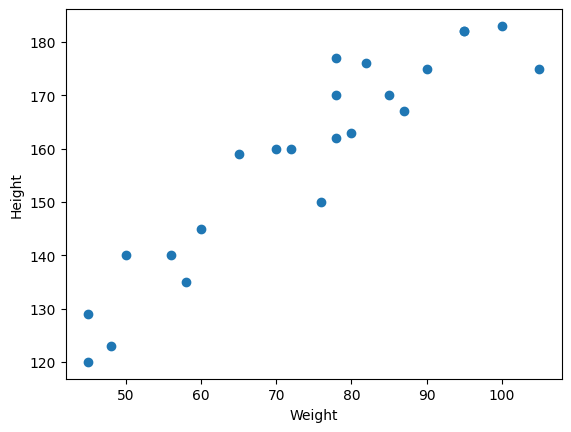

In [169]:
#Scatter plot to visualize the relationship between height and weight
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [170]:
df.corr() #Check the correlation between height and weight

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


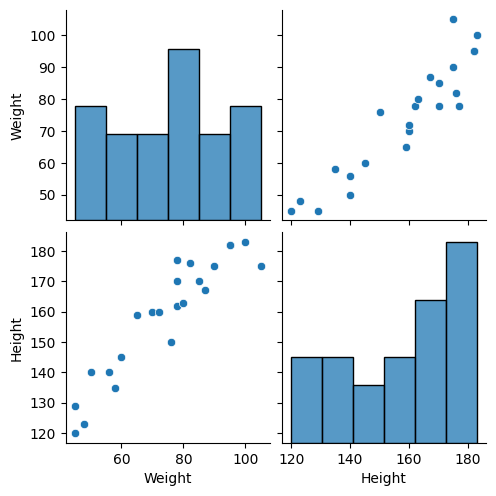

In [171]:
sns.pairplot(df)

In [172]:
X=df[['Weight']] #Independent variable should be in 2D array format
y=df['Height'] #Dependent variable can be 1D array format
print(X.shape)
print(y.shape)

(23, 1)
(23,)


In [173]:
#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [174]:
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0]) 


Training set size: 18
Testing set size: 5


In [175]:
#Standardization
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train) #Fit the scaler on the training data 

In [176]:
X_test=scaler.transform(X_test) #Transform the testing data using the fitted scaler

In [177]:
model=LinearRegression()

In [178]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [179]:
print(f'Coefficient (slope): {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coefficient (slope): [17.03440872]
Intercept: 157.5


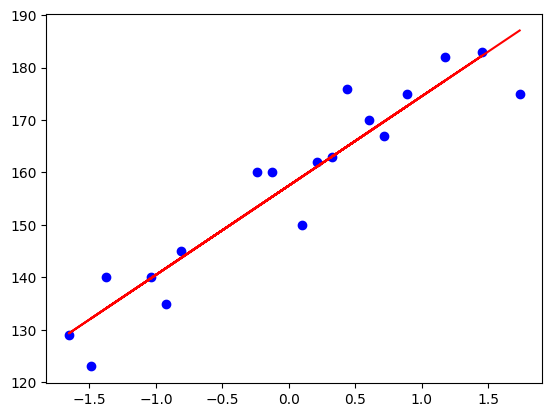

In [180]:
## Plotting the best fit line with training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Best Fit Line')

In [181]:
y_pred=model.predict(X_test)
y_pred

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

In [182]:
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
r_squared=r2_score(y_test, y_pred)
rmse=np.sqrt(mse)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared (Accuracy): {r_squared}')

Mean Squared Error: 109.77592599051664
Mean Absolute Error: 9.822657814519232
Root Mean Squared Error: 10.477400726827081
R-squared (Accuracy): 0.776986986042344


In [183]:
## Function to predict height based on weight
def predict_height(weight):
    scaled_weight = scaler.transform([[weight]]) 
    predicted_height = model.predict(scaled_weight)  
    return predicted_height[0]  

In [ ]:
## Predict the height for a weight of 45
print(f'Height for weight 45: {predict_height(45)}')

Height for weight 45: 129.30415610295063


d:\150-days-of-ai-and-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
